# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Task 1: Problem Identification

The dataset represents an Image Classification problem.

- The dataset contains images grouped into separate folders such as Dent, Scratch, Stain, and Normal.
- Each folder represents a different class or category.
- The goal of the model is to examine an image and predict which category it belongs to.
- The model only needs to assign one label to the entire image.
- It does not need to locate defects using bounding boxes or mark pixels of the defect area.
- Therefore, the dataset is best suited for an Image Classification task.


Number of Classes = 4

Class:normal
Number of images:120

Class:scratch
Number of images:120

Class:dent
Number of images:120

Class:stain
Number of images:120


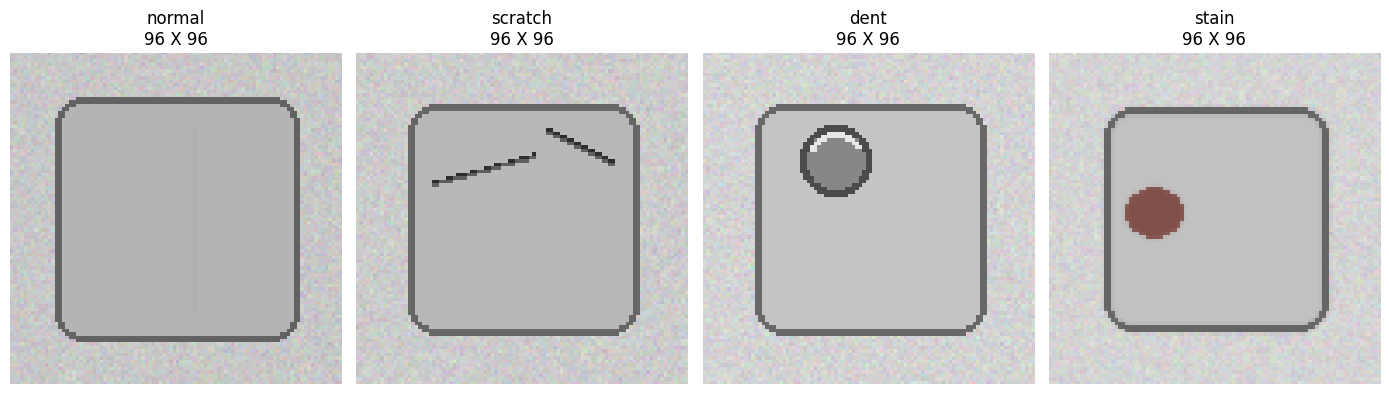


Image Dimensions (First 5 images of each class):

Class:normal
('normal', 'normal_001.png', 96, 96)
('normal', 'normal_002.png', 96, 96)
('normal', 'normal_003.png', 96, 96)
('normal', 'normal_004.png', 96, 96)
('normal', 'normal_005.png', 96, 96)

Class:scratch
('normal', 'normal_001.png', 96, 96)
('normal', 'normal_002.png', 96, 96)
('normal', 'normal_003.png', 96, 96)
('normal', 'normal_004.png', 96, 96)
('normal', 'normal_005.png', 96, 96)

Class:dent
('normal', 'normal_001.png', 96, 96)
('normal', 'normal_002.png', 96, 96)
('normal', 'normal_003.png', 96, 96)
('normal', 'normal_004.png', 96, 96)
('normal', 'normal_005.png', 96, 96)

Class:stain
('normal', 'normal_001.png', 96, 96)
('normal', 'normal_002.png', 96, 96)
('normal', 'normal_003.png', 96, 96)
('normal', 'normal_004.png', 96, 96)
('normal', 'normal_005.png', 96, 96)

The dataset is fairly balanced.


In [31]:
## Task 2: Dataset Exploration

import os
from PIL import Image
import matplotlib.pyplot as plt

### Dataset Path
dataset_path = "images"

### Number of Classes
classes = ['normal','scratch','dent','stain']

num_classes = len(classes)

print(f'\nNumber of Classes = {num_classes}')

### Number of images per class

image_counts = {}
image_dimensions = []                          

for cls in classes:

    class_path = os.path.join(dataset_path,cls)

    images = os.listdir(class_path)

    image_counts[cls] = len(images)

    print(f'\nClass:{cls}')
    print(f'Number of images:{image_counts[cls]}')

    # --Store Dimensions for All Images

    for image_name in images:

        image_path = os.path.join(class_path,image_name)

        img = Image.open(image_path)

        width, height = img.size

        image_dimensions.append((cls,image_name,width,height))


### Display Sample images from each class with dimensions

plt.figure(figsize=(14,4))

for i,cls in enumerate(classes):

    class_path = os.path.join(dataset_path,cls)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path,image_name)

    img = Image.open(image_path)

    #  --Image Dimensions
    width, height = img.size

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    
    plt.title(f"{cls}\n{width} X {height}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nImage Dimensions (First 5 images of each class):")

for cls in classes:
    print(f'\nClass:{cls}')

    count = 0 
    for item in image_dimensions:
        print(item)
        count += 1

        if count == 5:
            break


### Imbalance in the dataset

#Check

counts = list(image_counts.values())

if max(counts) - min(counts) <= 10:
    print("\nThe dataset is fairly balanced.")
else:
    print("\nThe dataset is fairly balanced because all classes contain a similar number of images.")


In [32]:
## Task 3: Image Preprocessing

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Path
dataset_path = "images"

# Image Parameters
img_height = 128
img_width = 128
batch_size = 32

# Training Data Generator
train_datagen = ImageDataGenerator(

    # Normalize Pixel Values
    rescale = 1./255,

    # Split dataset
    validation_split = 0.2,

    # Data Augmentation
    rotation_range = 15,
    zoom_range = 0.1,
    horizontal_flip = True
)

# Training Dataset

train_data = train_datagen.flow_from_directory(

    dataset_path,
    target_size = (img_height,img_width),  # Resize Images
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'training'
)

## Testing / Validation Data

test_datagen = ImageDataGenerator(

    rescale = 1./255,
    validation_split = 0.2
)

test_data = test_datagen.flow_from_directory(
    dataset_path,
    target_size = (img_height,img_width),  # Resize Images
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'validation'
)

print("\nClass Labels:")
print(train_data.class_indices)

print("\nNumber of Training Images:")
print(train_data.samples)

print("\nNumber of Testing Images:")
print(test_data.samples)

print("\nImage Shape After Resizing:")
print((img_height,img_width,3))

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.

Class Labels:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}

Number of Training Images:
384

Number of Testing Images:
96

Image Shape After Resizing:
(128, 128, 3)


In [33]:
## Task 4: CNN Model Creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# CNN Model Creation

model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',      # Activation function
        input_shape = (128,128,3)
    )
)

# First Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'       # Activation function
    )
)

# Second Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(
    Dense(
        units=128,
        activation='relu'           # Activation function
    ))

# Output Layer
model.add(
    Dense(
        units=4,
        activation='softmax'        # Activation function
    ))

# Compile Model
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# Model Summary
model.summary()

c:\Users\natas\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 435ms/step - accuracy: 0.2474 - loss: 2.4983 - val_accuracy: 0.2500 - val_loss: 1.3907
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 410ms/step - accuracy: 0.3203 - loss: 1.3747 - val_accuracy: 0.3333 - val_loss: 1.3483
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step - accuracy: 0.3802 - loss: 1.3023 - val_accuracy: 0.4688 - val_loss: 1.2191
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.5182 - loss: 1.1407 - val_accuracy: 0.6562 - val_loss: 0.9670
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 354ms/step - accuracy: 0.5312 - loss: 1.0371 - val_accuracy: 0.5833 - val_loss: 1.0188
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 0.7057 - loss: 0.8475 - val_accuracy: 0.7604 - val_loss: 0.6881
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 714ms/step - accuracy: 0.7526 - loss: 0.6434 - val_accuracy: 0.6667 - val_loss: 0.7939
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 468ms/step - accuracy: 0.7865 - loss: 0.6057 - val_accuracy: 0.

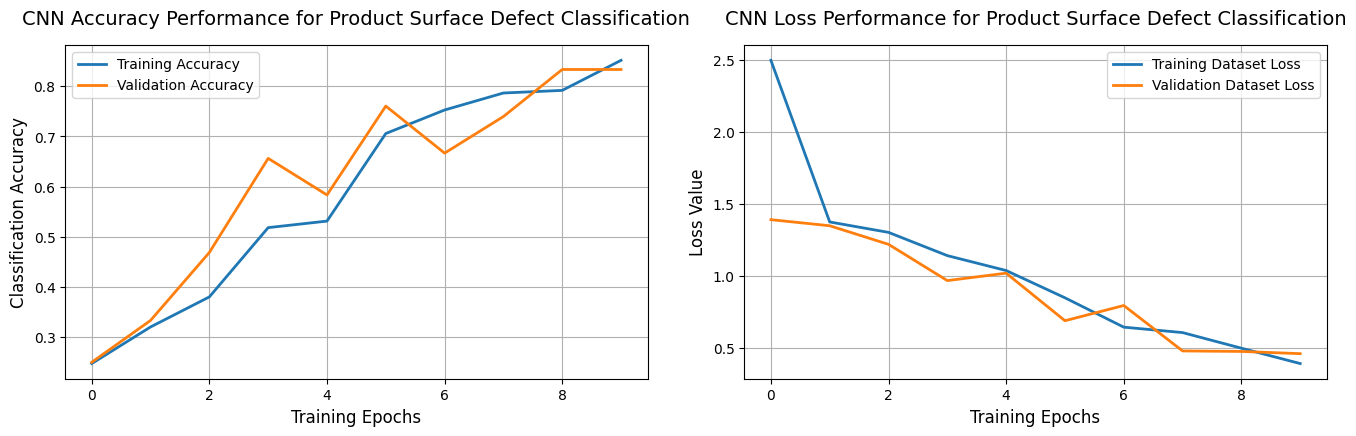

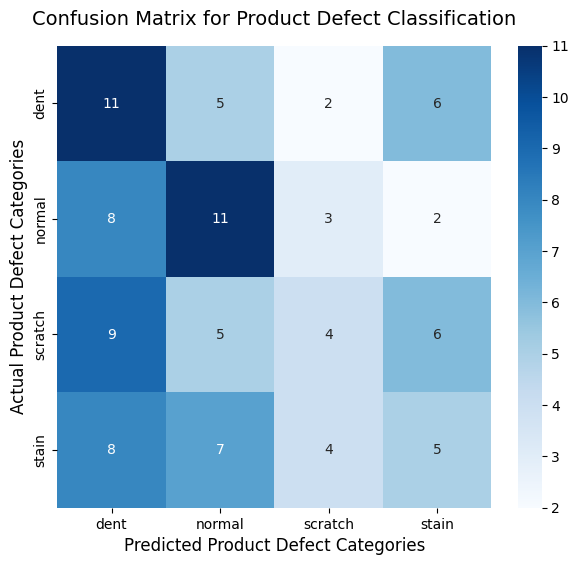

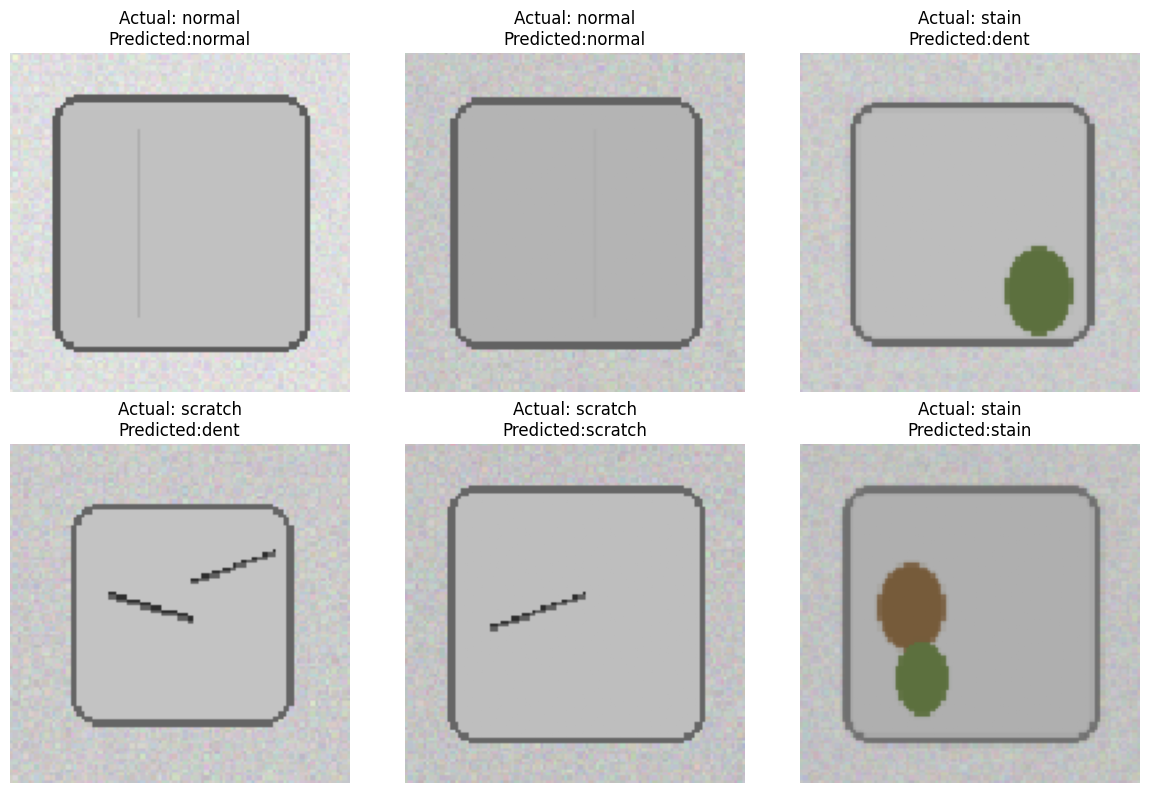

In [34]:
## Task 5: Model Training and Evaluation
import os
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

#Create output folders

os.makedirs('sample_predictions',exist_ok=True)
os.makedirs('results',exist_ok=True)

# Traing CNN Model

history = model.fit(
    train_data,
    validation_data = test_data,
    epochs = 10
)

# Accuracy and Loss Curves
plt.figure(figsize=(14,5))

# Training vs Validation Accuracy

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label = 'Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label = 'Validation Accuracy',
    linewidth=2
)

plt.title('CNN Accuracy Performance for Product Surface Defect Classification', fontsize=14,pad=15)
plt.xlabel('Training Epochs',fontsize=12)
plt.ylabel('Classification Accuracy',fontsize=12)
plt.legend()
plt.grid(True)

# Training vs Validation Loss
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label = 'Training Dataset Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label = 'Validation Dataset Loss',
    linewidth=2
)

plt.title('CNN Loss Performance for Product Surface Defect Classification',fontsize=14,pad=15)
plt.xlabel('Training Epochs',fontsize=12)
plt.ylabel('Loss Value',fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout(pad=3)
plt.savefig("results/accuracy_loss_curves.png",bbox_inches='tight')


# Testing Performance

test_loss, test_accuracy = model.evaluate(test_data)

print(f"\nTesting Loss:{test_loss}")
print(f"\nTesting Accuracy:{test_accuracy}")

# Predictions
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions,axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Confusion Matrix

cm = confusion_matrix(true_classes,predicted_classes)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix for Product Defect Classification",fontsize=14,pad=15)
plt.xlabel('Predicted Product Defect Categories', fontsize=12)
plt.ylabel('Actual Product Defect Categories', fontsize=12)

plt.savefig('results/confusion_matrix.png', bbox_inches='tight')

#Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

# Sample Predictions

plt.figure(figsize=(12,8))

for images, labels in test_data:
    
    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    actual_labels = np.argmax(labels, axis = 1)

    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i])

        actual_class = class_labels[actual_labels[i]]
        predicted_class = class_labels[predicted_labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted:{predicted_class}"
        )

        plt.axis("off")

    break

plt.tight_layout()

# Save Sample Predictions

plt.savefig("sample_predictions/prediction_outputs.png")




## Task 6: CNN Concept Explanation

1) What is convolution?
Convolution is a process where the CNN scans small parts of an image to detect important features such as edges, textures, scratches, dents, or patterns.

2) Why is pooling used?
Pooling is used to reduce the size of image features while keeping the most important information. This helps make the model faster and reduces overfitting.

3) Why is ReLU commonly used in CNNs?
ReLU helps the CNN learn complex patterns by converting negative values to zero and keeping positive values unchanged. It also helps the model train faster.

4) Why are CNNs better than regular feed-forward networks for image data?
CNNs are designed specifically for images. They automatically learn important image features such as shapes, textures, and defects, while regular feed-forward networks cannot efficiently capture spatial patterns in images.

## Task 7: Business Use Case Mapping

Agriculture Use Case

This type of computer vision solution can be used in agriculture to identify defects or diseases in crops, fruits, and leaves using images. A CNN model can automatically classify healthy and unhealthy crops by detecting spots, stains, or damaged areas. This helps farmers monitor crop health early, reduce manual inspection effort, improve crop quality, and increase overall agricultural productivity.